# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *
from data_operations_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran


from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor
from econml.dml import DML, LinearDML, SparseLinearDML, CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import PolynomialFeatures

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import r2_score

In [2]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

# Data

In [13]:
dict_of_combs = {}

el3 = 5  

for el1 in range(5, 20):          
    el2 = el1 + 15                

    for el4 in range(9, 15):      
        for el5 in range(1, 17): 

            y = ((el2 - el1) + 1) * ((el4 - el3) + 1) - (16 - el5)

            # ograniczenie:
            # jeśli y == 80, to el5 musi być równe 16
            if y == 80 and el5 != 16:
                continue

            key = f"s_{el1}_{el2}_{el3}_{el4}_{el5}_{y}"

            dict_of_combs[key] = [el1, el2, el3, el4, el5, y]
for k in [k for k in dict_of_combs.keys() if int(k[-2:]) in list(range(65, 80))]:
    dict_of_combs.pop(k, None)

temp_list = ([k for k in dict_of_combs.keys() if int(k[-2:]) in list(range(65, 99,5))  and dict_of_combs[k][1]==28] 
    + [k for k in dict_of_combs.keys() if int(k[-2:]) in list(range(0, 61,5))  and dict_of_combs[k][1]==28])
temp_list

['s_13_28_5_9_16_80',
 's_13_28_5_10_5_85',
 's_13_28_5_10_10_90',
 's_13_28_5_10_15_95',
 's_13_28_5_11_4_100',
 's_13_28_5_11_9_105',
 's_13_28_5_11_14_110',
 's_13_28_5_12_3_115',
 's_13_28_5_12_8_120',
 's_13_28_5_12_13_125',
 's_13_28_5_13_2_130',
 's_13_28_5_13_7_135',
 's_13_28_5_13_12_140',
 's_13_28_5_14_1_145',
 's_13_28_5_14_6_150',
 's_13_28_5_14_11_155',
 's_13_28_5_14_16_160']

In [14]:
connection_link_var = repo_path_r_string + r'\03_simulated_data\simulated_data_ynsp.sqlite'
dict_of_gdfs = {}
for i in temp_list:

        df = import_non_spatial_data_frame(
                connection_link = connection_link_var,
                df_to_return_name =  i
        )
        gdf = gpd.GeoDataFrame(
                df,
                geometry=gpd.points_from_xy(df["x"], df["y"]),
                crs="EPSG:3857"
                )
        
        dict_of_gdfs[i] = gdf

In [16]:
dict_of_gdfs.keys()

dict_keys(['s_13_28_5_9_16_80', 's_13_28_5_10_5_85', 's_13_28_5_10_10_90', 's_13_28_5_10_15_95', 's_13_28_5_11_4_100', 's_13_28_5_11_9_105', 's_13_28_5_11_14_110', 's_13_28_5_12_3_115', 's_13_28_5_12_8_120', 's_13_28_5_12_13_125', 's_13_28_5_13_2_130', 's_13_28_5_13_7_135', 's_13_28_5_13_12_140', 's_13_28_5_14_1_145', 's_13_28_5_14_6_150', 's_13_28_5_14_11_155', 's_13_28_5_14_16_160'])

<Axes: >

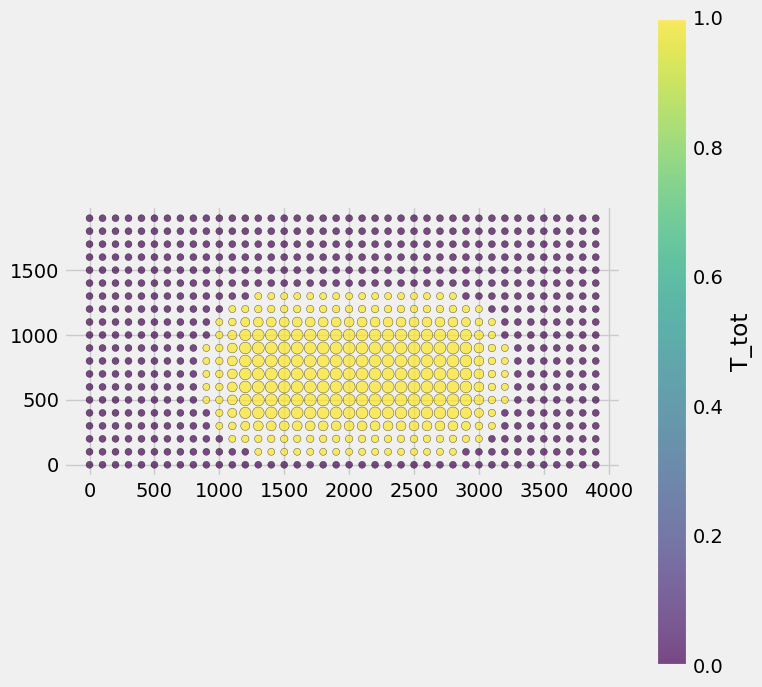

In [17]:

temp_gdf = dict_of_gdfs['s_13_28_5_9_16_80'].copy()
temp_gdf['spill2'] = temp_gdf['spill'] + 0.5
plot_gdf_points(temp_gdf, size_col='spill2',
    color_col='T_tot')

<Axes: >

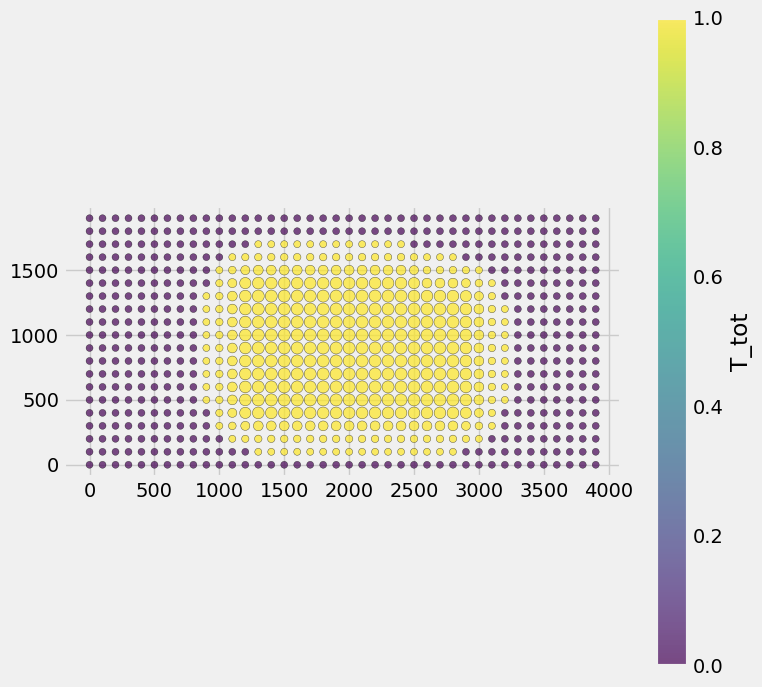

In [18]:

temp_gdf = dict_of_gdfs['s_13_28_5_13_12_140'].copy()
temp_gdf['spill2'] = temp_gdf['spill'] + 0.5
plot_gdf_points(temp_gdf, size_col='spill2',
    color_col='T_tot')

<Axes: >

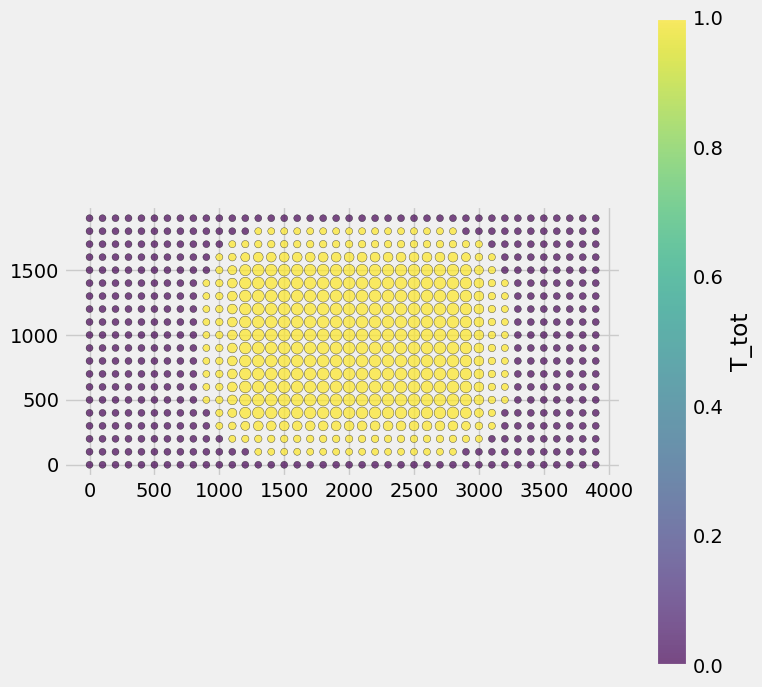

In [19]:

temp_gdf = dict_of_gdfs['s_13_28_5_14_16_160'].copy()
temp_gdf['spill2'] = temp_gdf['spill'] + 0.5
plot_gdf_points(temp_gdf, size_col='spill2',
    color_col='T_tot')

In [26]:
dict_of_combs['s_13_28_5_14_16_160'][5]/8

20.0

In [11]:
dict_of_gdfs['s_13_28_5_14_16_160'].columns.tolist()

['unit_id',
 'x',
 'y',
 'T',
 'T_tot',
 'T_tot_cat',
 'ODR_1',
 'ODR_2',
 'ODR_3',
 'ODR_4',
 'Cont_T_N',
 'C1',
 'C2',
 'tau',
 'spill',
 'Y_dep_var',
 'Y_dep_var_ns',
 'geometry']

# Modelling causal inference

In [9]:
replacing_dict_0_ring = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2', 3:'treated_outer_ring3'
                                             }

replacing_dict_odr_ring = {'T':'treated_inner_ring', 
                                                                        'ODR_1':'treated_outer_ring1', 
                                                                        'ODR_2':'treated_outer_ring2',
                                                                        'ODR_3':'treated_outer_ring3'
                                                                          }

In [12]:
dict_of_gdfs.keys()

dict_keys(['s_13_28_5_9_16_80', 's_13_28_5_10_5_85', 's_13_28_5_10_10_90', 's_13_28_5_10_15_95', 's_13_28_5_11_4_100', 's_13_28_5_11_9_105', 's_13_28_5_11_14_110', 's_13_28_5_12_3_115', 's_13_28_5_12_8_120', 's_13_28_5_12_13_125', 's_13_28_5_13_2_130', 's_13_28_5_13_7_135', 's_13_28_5_13_12_140', 's_13_28_5_14_1_145', 's_13_28_5_14_6_150', 's_13_28_5_14_11_155', 's_13_28_5_14_16_160'])

In [27]:
list_of_output_dfs = []
for i in  dict_of_gdfs.keys():
        
    # =========================================================
    # 0. Data preparation
    # =========================================================

    temp_gdf = dict_of_gdfs[i].copy()

    temp_gdf['t_tot_cat3'] =temp_gdf['T_tot_cat']
    temp_gdf.loc[temp_gdf['T_tot_cat']=='treated_outer_ring4', 't_tot_cat3'] = 'control'

    df_effectbase = pd.DataFrame({
                    'ring':['treated_inner_ring', 'treated_outer_ring1', 'treated_outer_ring2','treated_outer_ring3',
                            #'treated_outer_ring4'
                            ],
                'true_effect':[temp_gdf[temp_gdf['T'] == 1]['tau'].mean(), temp_gdf[temp_gdf['ODR_1'] == 1]['tau'].mean(), 
                                temp_gdf[temp_gdf['ODR_2'] == 1]['tau'].mean(), temp_gdf[temp_gdf['ODR_3'] == 1]['tau'].mean(), 
                                ],
                })


    X = temp_gdf[["C1","C2"]].values
    T_M= temp_gdf['t_tot_cat3'].values
    T_M= T_M.astype(str)
    Y = temp_gdf['Y_dep_var_ns'].values

    T_mult = temp_gdf[[ 
            'T', 'ODR_1','ODR_2','ODR_3',
            #'treated_outer_ring4'
            ]].to_numpy()

    T_D_id = temp_gdf[[ 
            'T', 'Cont_T_N'
            ]].to_numpy()


    Xdf_did = temp_gdf[['T', 'ODR_1','ODR_2','ODR_3', 
                "C1","C2"
            ]]
    X_did = sm.add_constant(Xdf_did)
    y_did = temp_gdf['Y_dep_var_ns']


    # =========================================================
    # 1. Multi-treatment S-Learner (distance rings)
    # =========================================================


    mS_learn = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')

    ite_mS_learn = mS_learn.fit_predict(X, T_M, Y)


    ITE_df_mSlearn = pd.DataFrame(ite_mS_learn).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                                2:'treated_outer_ring2', 3:'treated_outer_ring3',
                                                })
    ITE_df_mSlearn['treated'] = T_M


    df_multi_treatment_effects_Slearn = make_treatment_effects_df(ITE_df_mSlearn,  [ 'treated_inner_ring','treated_outer_ring1',
                'treated_outer_ring2','treated_outer_ring3', 
                ],'mSlearn', treated_col='treated')


    df_multi_effect_pre1 = df_effectbase.merge(df_multi_treatment_effects_Slearn, on = 'ring', how= 'left')

    # =========================================================
    # 2. Multi-treatment Causal Forest DML (distance rings)
    # =========================================================

    mCF = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                        model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                                max_depth=3,
                                                                                min_samples_leaf=20)),
                        cv=None,
                        criterion='mse', n_estimators=1000,
                        min_samples_leaf=10,
                        min_impurity_decrease=0.001,
                        random_state=123)

    mCF.tune(Y, T_mult, X=X, 
            #W=W
            )
    mCF.fit(Y, T_mult, X=X, 
            #W=W
            )

    mCF_pred = mCF.const_marginal_effect(X)
    ITE_mCF=pd.DataFrame(mCF_pred).rename(columns = replacing_dict_0_ring)

    ITE_mCF['treated'] = T_M
    df_multi_treatment_effects_mCF = make_treatment_effects_df(ITE_mCF,  ['treated_inner_ring','treated_outer_ring1',
                'treated_outer_ring2','treated_outer_ring3', 
                #'treated_outer_ring4'
                ],'mCF', treated_col='treated')

    df_multi_effect_pre2 = df_multi_effect_pre1.merge(df_multi_treatment_effects_mCF, on = 'ring', how= 'left')

    # =========================================================
    # 3. Double-treatment Causal Forest DML (inverse distance from treated)
    # =========================================================

    dCF = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                        model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                                max_depth=3,
                                                                                min_samples_leaf=20)),
                        cv=None,
                        criterion='mse', n_estimators=1000,
                        min_samples_leaf=10,
                        min_impurity_decrease=0.001,
                        random_state=123)

    dCF.tune(Y, T_D_id, X=X, 
            #W=W
            )
    dCF.fit(Y, T_D_id, X=X, 
            #W=W
            )

    dCF_pred = dCF.const_marginal_effect(X)
    ITE_dCF=pd.DataFrame(dCF_pred).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_rings', 

                                                })

    ITE_dCF['treated'] = T_M

    ITE_dCF['treated_outer_ring1'] = ITE_dCF['treated_outer_rings']
    ITE_dCF['treated_outer_ring2'] = ITE_dCF['treated_outer_rings']/2
    ITE_dCF['treated_outer_ring3'] = ITE_dCF['treated_outer_rings']/3

    df_multi_treatment_effects_dCF = make_treatment_effects_df(ITE_dCF,  ['treated_inner_ring','treated_outer_ring1',
                'treated_outer_ring2','treated_outer_ring3', 
                #'treated_outer_ring4'
                ],'dCF', treated_col='treated')

    df_multi_effect_pre3 = df_multi_effect_pre2.merge(df_multi_treatment_effects_dCF, on = 'ring', how= 'left')


    # =========================================================
    # 4. Multi-treatment Difference in Differences (distance rings)
    # =========================================================

    model_did = sm.OLS(y_did, X_did)
    results_did = model_did.fit()

    coef_df_did = pd.DataFrame({
        "ring": results_did.params.index,
        "att_mDiD": results_did.params.values,
        "se_mDiD": results_did.bse.values
    })

    coef_df_did = coef_df_did[coef_df_did['ring'].isin(['T', 
                                                                'ODR_1', 'ODR_2',
                                                                'ODR_3',
                                                                ])].copy()
    coef_df_did['ring'] = coef_df_did['ring'].replace(replacing_dict_odr_ring)

    df_multi_effect_temp = df_multi_effect_pre3.merge(coef_df_did, on = 'ring', how= 'left')
    df_multi_effect_temp['treat_size'] = dict_of_combs[i][5]/8
    df_multi_effect_temp = df_multi_effect_temp[['treat_size', 'ring',
            'true_effect',
            'att_mSlearn',
            'se_mSlearn',
            'att_mCF',
            'se_mCF',
            'att_dCF',
            'se_dCF',
            'att_mDiD',
            'se_mDiD']]
    list_of_output_dfs.append(df_multi_effect_temp)
df_results = pd.concat(list_of_output_dfs)
#df_results['rho'] = df_results['rho'].str[2:].astype(float)/1000
df_results

,treat_size,ring,true_effect,att_mSlearn,se_mSlearn,att_mCF,se_mCF,att_dCF,se_dCF,att_mDiD,se_mDiD
0,10.000,treated_inner_ring,1.500000,1.338329,0.082089,1.349286,0.045545,1.321406,0.031606,1.364601,0.105567
1,10.000,treated_outer_ring1,0.888615,0.775189,0.077401,0.982020,0.051756,0.983319,0.022511,0.949430,0.141453
2,10.000,treated_outer_ring2,0.535973,0.319584,0.055899,0.509244,0.054085,0.482908,0.009638,0.599737,0.135625
3,10.000,treated_outer_ring3,0.111990,0.089761,0.035510,0.184343,0.035234,0.321680,0.007900,0.164616,0.126034
0,10.625,treated_inner_ring,1.500000,1.433892,0.084466,1.496757,0.030576,1.503105,0.034786,1.509031,0.103223
...,...,...,...,...,...,...,...,...,...,...,...
3,19.375,treated_outer_ring3,0.120045,0.159797,0.031621,0.239753,0.012673,0.292202,0.012187,0.260351,0.116536
0,20.000,treated_inner_ring,1.500000,1.495609,0.057231,1.445741,0.023258,1.455547,0.029146,1.505101,0.077657
1,20.000,treated_outer_ring1,0.913198,0.611307,0.071747,0.942711,0.040857,0.972002,0.048403,0.909751,0.123966
2,20.000,treated_outer_ring2,0.531133,0.324467,0.050965,0.507540,0.025807,0.449668,0.019467,0.513817,0.120081


# Results visualization

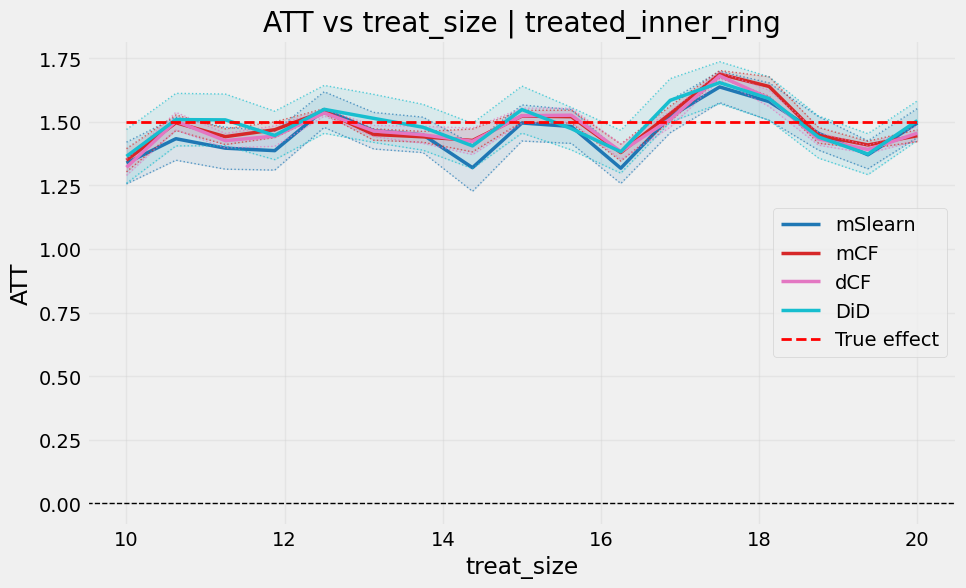

In [28]:
models = {
    "mSlearn": ("att_mSlearn", "se_mSlearn"),
    "mCF": ("att_mCF", "se_mCF"),
    'dCF' : ('att_dCF', 'se_dCF'),
    "DiD": ("att_mDiD", "se_mDiD")
}

plot_att_by_param(
    df_results,
    param_col="treat_size",
    ring_value="treated_inner_ring",
    models_dict=models
)

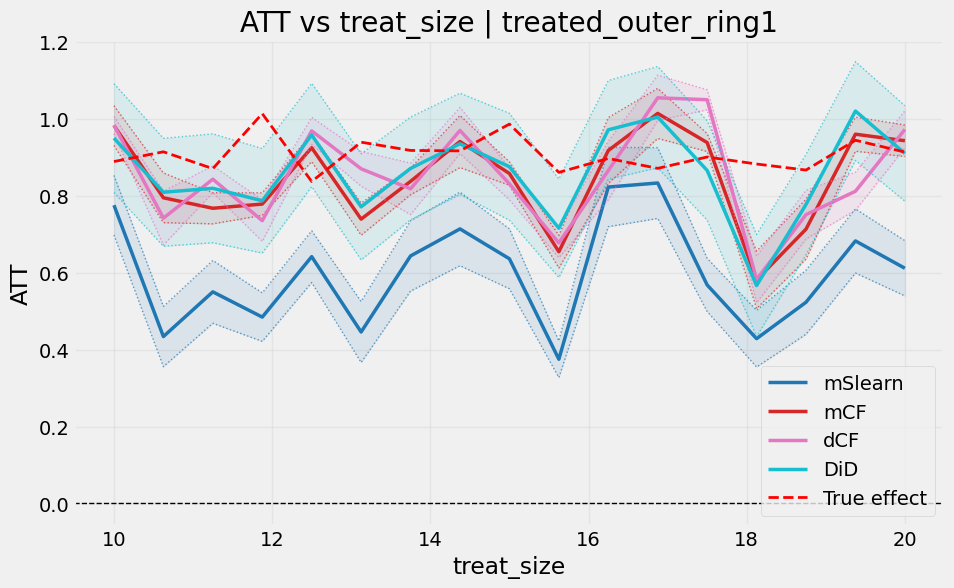

In [29]:
plot_att_by_param(
    df_results,
    param_col="treat_size",
    ring_value="treated_outer_ring1",
    models_dict=models
)

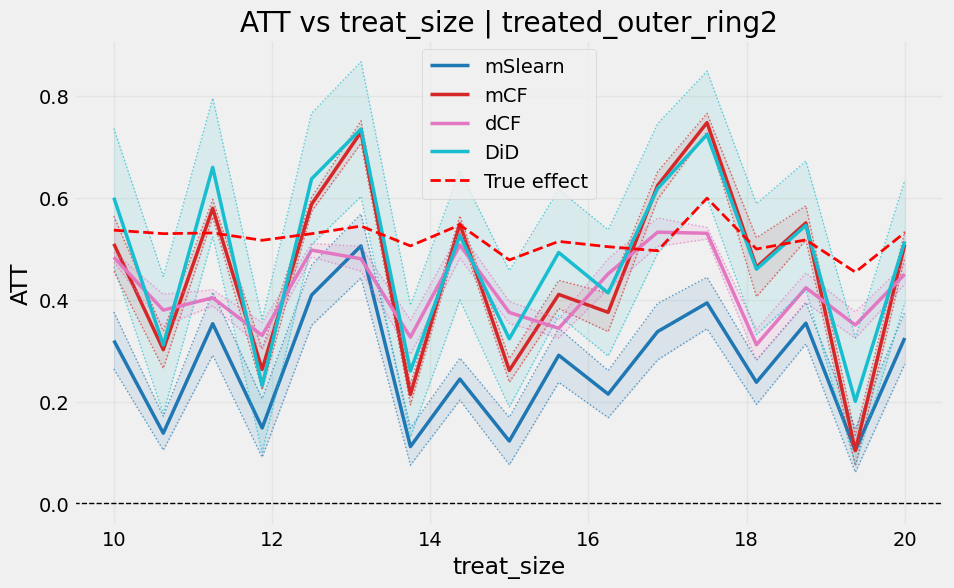

In [30]:
plot_att_by_param(
    df_results,
    param_col="treat_size",
    ring_value="treated_outer_ring2",
    models_dict=models
)

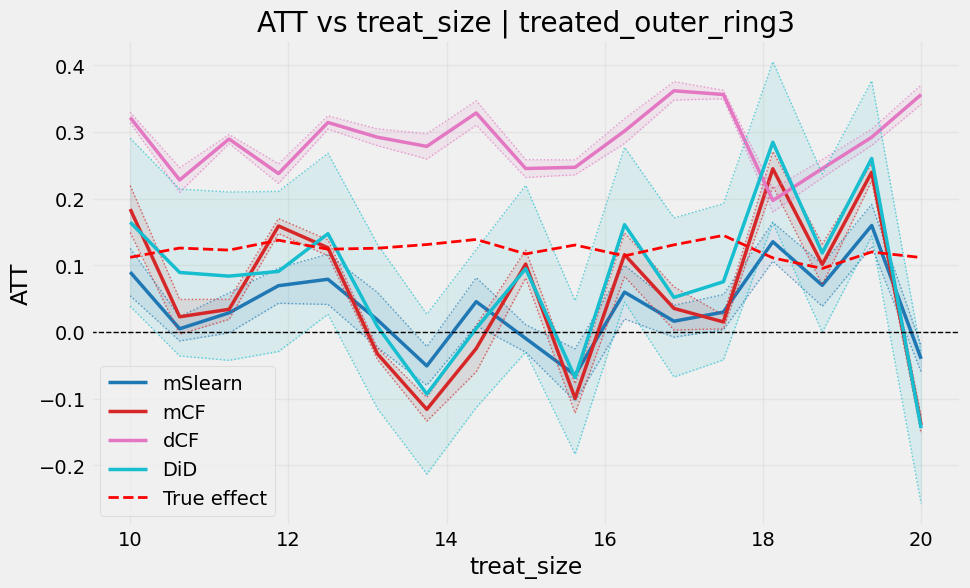

In [31]:
plot_att_by_param(
    df_results,
    param_col="treat_size",
    ring_value="treated_outer_ring3",
    models_dict=models
)